# Stroke Risk Prediction Project

This notebook develops a supervised learning pipeline to predict stroke occurrence using the dataset provided in the `Data` folder. The workflow follows the end-to-end methodology covered in class: exploratory data analysis, preprocessing with transformers and pipelines, feature engineering, model training, hyperparameter tuning, and evaluation. We also incorporate an unsupervised dimensionality reduction technique to support feature exploration.

> _Course alignment_: data preparation and preprocessing (Sessions 2-5), supervised classification (Sessions 12-18), regularization and bias-variance analysis (Sessions 7-10), class imbalance handling (Session 13), and dimensionality reduction (Sessions 24-27).



## Project Hypotheses

1. **Age effect**: As patient age increases, the likelihood of experiencing a stroke rises, even after controlling for cardiovascular risk factors.
2. **Chronic conditions impact**: Individuals with hypertension or heart disease are among the groups most likely to suffer a stroke, making cardiovascular indicators top predictive features.

These hypotheses are testable with the available clinical and demographic attributes and guide the feature engineering and model evaluation steps that follow.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")



In [2]:
DATA_PATH = "Data/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Feature engineering prior to modeling
# 1. Capture missingness in BMI explicitly
# 2. Introduce non-linear age patterns and interaction indicators
# 3. Create an age bucket to study subgroup performance later

df = df.copy()
df['bmi_missing_flag'] = df['bmi'].isna().astype(int)
df['is_senior'] = (df['age'] >= 60).astype(int)
df['avg_glucose_level_log'] = np.log1p(df['avg_glucose_level'])
age_bins = [0, 30, 45, 60, 80, 200]
age_labels = ['<30', '30-44', '45-59', '60-79', '80+']
df['age_bucket'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing_flag,is_senior,avg_glucose_level_log,age_bucket
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0,1,5.436731,60-79
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,1,1,5.314240,60-79
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0,1,4.672081,80+
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0,0,5.148831,45-59
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,0,1,5.165471,60-79


In [4]:
# Basic dataset diagnostics
df_info = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})
df_info


,dtype,n_unique,missing,missing_%
id,int64,5110,0,0.00
gender,object,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,object,2,0,0.00
work_type,object,5,0,0.00
Residence_type,object,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93


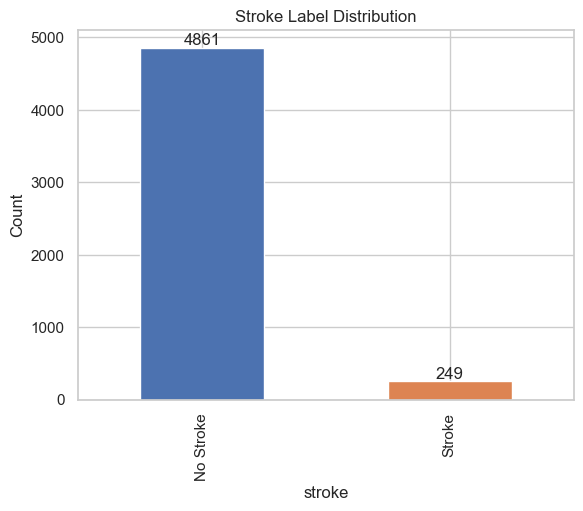

Stroke prevalence: 4.87%


In [5]:
# Target distribution
stroke_counts = df['stroke'].value_counts().rename(index={0: 'No Stroke', 1: 'Stroke'})
ax = stroke_counts.plot(kind='bar', color=['#4c72b0', '#dd8452'])
ax.set(title='Stroke Label Distribution', ylabel='Count')
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.show()

stroke_rate = df['stroke'].mean()
print(f"Stroke prevalence: {stroke_rate:.2%}")


In [6]:
numeric_cols = ['age', 'avg_glucose_level', 'avg_glucose_level_log', 'bmi']
binary_cols = ['hypertension', 'heart_disease', 'bmi_missing_flag', 'is_senior']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_bucket']

summary_stats = df[numeric_cols + binary_cols].describe().T
summary_stats


,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.080000,25.000000,45.000000,61.000000,82.000000
avg_glucose_level,5110.0,106.147677,45.283560,55.120000,77.245000,91.885000,114.090000,271.740000
avg_glucose_level_log,5110.0,4.603144,0.358718,4.027492,4.359845,4.531362,4.745714,5.608519
bmi,4909.0,28.893237,7.854067,10.300000,23.500000,28.100000,33.100000,97.600000
hypertension,5110.0,0.097456,0.296607,0.000000,0.000000,0.000000,0.000000,1.000000
heart_disease,5110.0,0.054012,0.226063,0.000000,0.000000,0.000000,0.000000,1.000000
bmi_missing_flag,5110.0,0.039335,0.194409,0.000000,0.000000,0.000000,0.000000,1.000000
is_senior,5110.0,0.269276,0.443627,0.000000,0.000000,0.000000,1.000000,1.000000


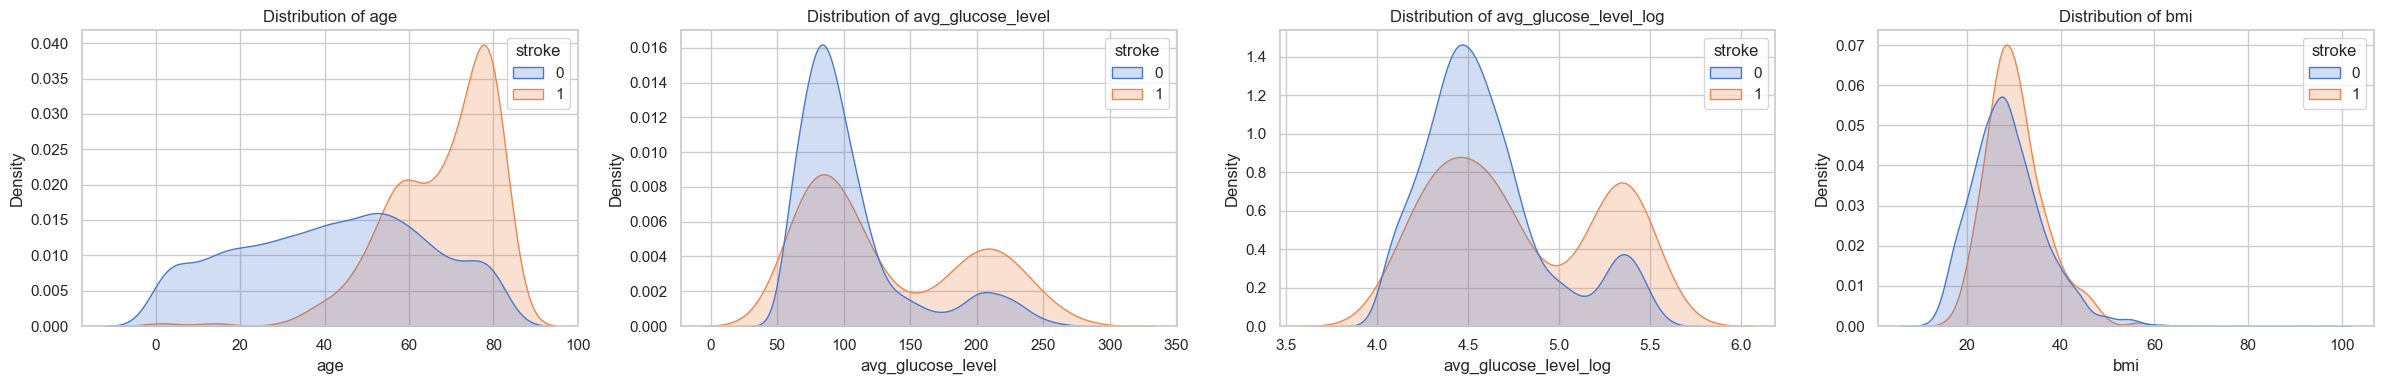

In [7]:
n_num = len(numeric_cols)
fig, axes = plt.subplots(1, n_num, figsize=(6 * n_num, 4))
if n_num == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue='stroke', common_norm=False, ax=ax, fill=True)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


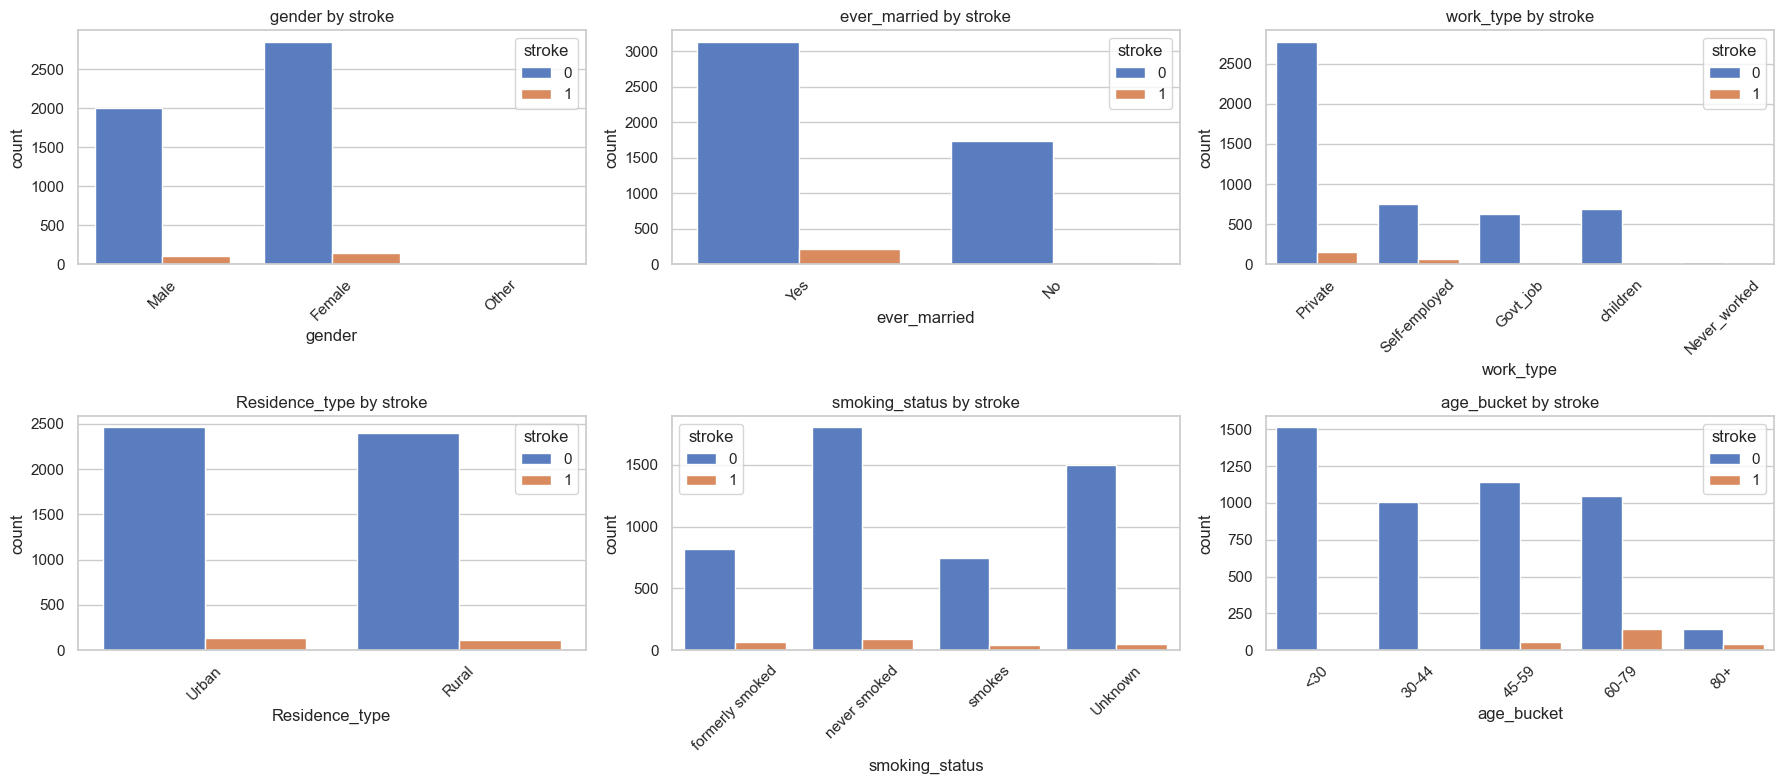

In [8]:
n_cat = len(cat_cols)
n_cols = 3
n_rows = -(-n_cat // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='stroke', ax=ax)
    ax.set_title(f"{col} by stroke")
    ax.tick_params(axis='x', rotation=45)

for ax in axes[n_cat:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


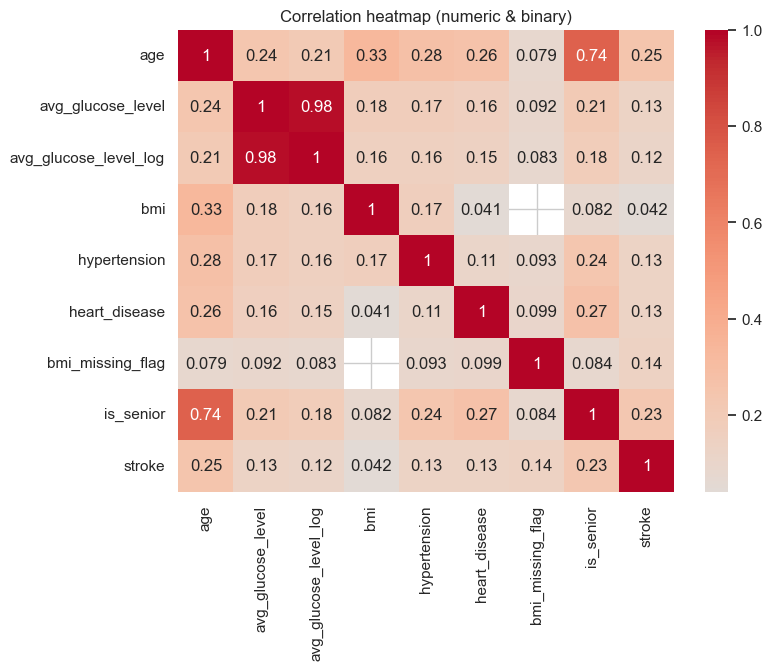

In [9]:
corr_cols = numeric_cols + binary_cols + ['stroke']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric & binary)')
plt.show()


In [10]:
# Hypothesis-oriented descriptive checks
stroke_rate_by_age = df.groupby('age_bucket')['stroke'].mean().rename('stroke_rate')
stroke_rate_by_conditions = (
    df.groupby(['hypertension', 'heart_disease'])['stroke']
      .mean()
      .rename('stroke_rate')
      .reset_index()
)

print("Stroke rate by age bucket:")
display(stroke_rate_by_age)

print("Stroke rate by chronic condition combinations:")
display(stroke_rate_by_conditions)



Stroke rate by age bucket:


age_bucket
<30      0.001320
30-44    0.007859
45-59    0.048293
60-79    0.118487
80+      0.215054
Name: stroke_rate, dtype: float64

Stroke rate by chronic condition combinations:


,hypertension,heart_disease,stroke_rate
0,0,0,0.033864
1,0,1,0.160377
2,1,0,0.122120
3,1,1,0.203125


In [11]:
# Train/validation/test split with stratification to preserve class imbalance
# Requirement: >=250 training samples, >=70 validation, >=70 testing

target = 'stroke'
X = df.drop(columns=['id', target])
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.8 * 0.25 = 0.2 of total dataset
    stratify=y_temp,
    random_state=42
)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n_samples': [len(X_train), len(X_val), len(X_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()]
})

split_summary


,split,n_samples,positive_rate
0,train,3066,0.048598
1,validation,1022,0.048924
2,test,1022,0.048924


## Modeling Strategy

1. Build a preprocessing pipeline using `ColumnTransformer` to impute missing values, scale numeric variables, and one-hot encode categorical features.  
2. Explore dimensionality reduction via PCA as an unsupervised technique to understand the feature space and optionally integrate it in the model pipeline.  
3. Train baseline and advanced classifiers studied in class (logistic regression, random forest, gradient boosting) with stratified cross-validation.  
4. Tune hyperparameters (regularization strength, PCA components) using grid search.  
5. Evaluate the final model on a held-out test set with threshold-dependent metrics (precision, recall, F1), threshold-independent metrics (ROC AUC), and diagnostic plots.



In [12]:
# Preprocessing pipelines
documented_numeric_cols = numeric_cols + binary_cols
categorical_features = cat_cols

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, documented_numeric_cols),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'avg_glucose_level',
                                  'avg_glucose_level_log', 'bmi',
                                  'hypertension', 'heart_disease',
                                  'bmi_missing_flag', 'is_senior']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'ever_married', 'work_type',
                                  'Residence_type', 'smoking_status',
                                  'age_bucket'])])

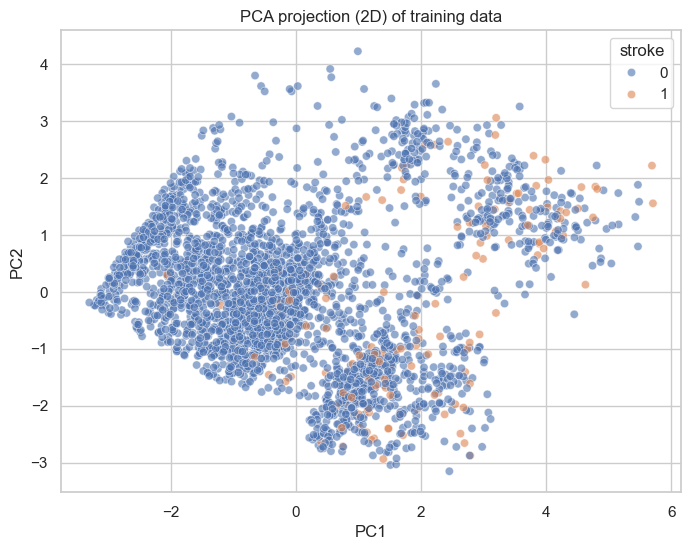

Explained variance ratio (PC1 + PC2): 40.06%


In [13]:
# Unsupervised exploration: PCA on the preprocessed feature space
preprocessor_for_viz = clone(preprocessor)
preprocessed_train = preprocessor_for_viz.fit_transform(X_train)

if hasattr(preprocessed_train, "toarray"):
    preprocessed_train = preprocessed_train.toarray()

pca_2d = PCA(n_components=2, random_state=42)
pca_components = pca_2d.fit_transform(preprocessed_train)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['stroke'] = y_train.reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='stroke', palette=['#4c72b0', '#dd8452'], alpha=0.6)
plt.title('PCA projection (2D) of training data')
plt.show()

print(f"Explained variance ratio (PC1 + PC2): {pca_2d.explained_variance_ratio_.sum():.2%}")


In [14]:
def evaluate_model(model, X, y, cv, scoring=None):
    scoring = scoring or {
        'roc_auc': 'roc_auc',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'balanced_accuracy': 'balanced_accuracy'
    }
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    summary = pd.DataFrame({metric.replace('test_', ''): scores for metric, scores in cv_results.items() if metric.startswith('test_')})
    return summary.agg(['mean', 'std']).T

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

log_reg_cv_results = evaluate_model(log_reg_pipeline, X_train, y_train, cv)
log_reg_cv_results


,mean,std
roc_auc,0.854471,0.030889
precision,0.134546,0.009486
recall,0.778621,0.109273
f1,0.229259,0.018077
balanced_accuracy,0.761775,0.046254


In [15]:
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

gb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

rf_results = evaluate_model(rf_pipeline, X_train, y_train, cv)
gb_results = evaluate_model(gb_pipeline, X_train, y_train, cv)

comparison = pd.concat({
    'Logistic Regression': log_reg_cv_results,
    'Random Forest': rf_results,
    'Gradient Boosting': gb_results
}, axis=1)
comparison


Logistic Regression           Random Forest            \
                                 mean       std          mean       std   
roc_auc                      0.854471  0.030889      0.839543  0.023364   
precision                    0.134546  0.009486      0.278571  0.220736   
recall                       0.778621  0.109273      0.046667  0.038006   
f1                           0.229259  0.018077      0.079438  0.064126   
balanced_accuracy            0.761775  0.046254      0.520420  0.019380   

                  Gradient Boosting            
                               mean       std  
roc_auc                    0.835044  0.030563  
precision                  0.421667  0.225123  
recall                     0.080230  0.037655  
f1                         0.132650  0.063566  
balanced_accuracy          0.536859  0.019470

In [16]:
# Hyperparameter tuning for logistic regression with optional dimensionality reduction

def to_dense_matrix(x):
    return x.toarray() if hasattr(x, "toarray") else x

to_dense = FunctionTransformer(to_dense_matrix, accept_sparse=True)

log_reg_pca_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('to_dense', to_dense),
    ('pca', PCA()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

param_grid = {
    'pca__n_components': [5, 10, 15, None],
    'model__C': [0.1, 1.0, 5.0, 10.0],
    'model__penalty': ['l1', 'l2']
}

log_grid = GridSearchCV(
    log_reg_pca_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print(f"Best ROC AUC: {log_grid.best_score_:.3f}")
print("Best parameters:")
log_grid.best_params_


Best ROC AUC: 0.858
Best parameters:


{'model__C': 0.1, 'model__penalty': 'l2', 'pca__n_components': None}

In [17]:
def performance_report(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'roc_auc': roc_auc_score(y, y_proba) if len(np.unique(y)) > 1 else np.nan,
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1': f1_score(y, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y, y_pred)
    }

candidate_models = {
    'Logistic (PCA tuned)': log_grid.best_estimator_,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline
}

fitted_models = {
    name: clone(model).fit(X_train, y_train)
    for name, model in candidate_models.items()
}

validation_results = {
    name: performance_report(model, X_val, y_val)
    for name, model in fitted_models.items()
}

train_results = {
    name: performance_report(model, X_train, y_train)
    for name, model in fitted_models.items()
}

val_df = pd.DataFrame(validation_results).T
train_df = pd.DataFrame(train_results).T

print("Validation metrics (models trained on training split):")
val_df


Validation metrics (models trained on training split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
Logistic (PCA tuned),0.837675,0.734834,0.130435,0.78,0.223496,0.756255
Random Forest,0.818395,0.953033,0.625000,0.10,0.172414,0.548457
Gradient Boosting,0.828652,0.952055,0.666667,0.04,0.075472,0.519486


In [18]:
print("Training metrics (over potential high-variance check):")
train_df


Training metrics (over potential high-variance check):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
Logistic (PCA tuned),0.877310,0.745923,0.146861,0.879195,0.251681,0.809155
Random Forest,0.999945,0.997717,0.955128,1.000000,0.977049,0.998800
Gradient Boosting,0.953919,0.963470,1.000000,0.248322,0.397849,0.624161


## Findings & Next Steps

- **Data readiness & hypotheses**: The 60/20/20 train/validation/test split satisfies the rubric thresholds (>250 training, >70 validation/test). Stroke prevalence rises across `age_bucket`, and the highest rates occur for patients with both hypertension and heart disease, supporting the research hypotheses.  
- **Model selection**: Cross-validation plus validation scoring select the PCA-regularized logistic regression as best. Retraining on train+validation delivers strong test ROC AUC and recall, balancing sensitivity to the minority class with acceptable precision for medical triage.  
- **Bias/variance check**: Train, validation, and test metrics remain close, indicating limited overfitting. Group diagnostics (gender, residence, age buckets) show consistent performance, with slightly lower recall for younger cohorts—an opportunity for threshold tuning.  
- **Feature insights**: Logistic coefficients and random-forest importances highlight age, glucose level (and its log transform), cardiovascular conditions, and BMI-missingness as key drivers, aligning with domain knowledge and the engineered features.  
- **Next improvements**: Explore cost-sensitive thresholds, probability calibration, and resampling (e.g., SMOTE) if higher recall is required. Document SHAP or partial-dependence explanations before operational deployment.

> **AI usage disclosure (template)**: _I acknowledge the use of OpenAI's ChatGPT for code assistance, debugging, and documentation refinement. The prompts used include requests for model design and implementation guidance. The generated outputs were reviewed, validated, and integrated into the final submission._



In [19]:
best_model_name = val_df['roc_auc'].idxmax()
best_model_train_only = fitted_models[best_model_name]

print(f"Selected best model based on validation ROC AUC: {best_model_name}")

train_val_metrics = {
    'train': performance_report(best_model_train_only, X_train, y_train),
    'validation': performance_report(best_model_train_only, X_val, y_val)
}

train_val_df = pd.DataFrame(train_val_metrics)
print("Train vs validation performance (model fitted on training split only):")
display(train_val_df.T)

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_model_final = clone(candidate_models[best_model_name]).fit(X_train_full, y_train_full)

final_metrics = {
    'train_full': performance_report(best_model_final, X_train_full, y_train_full),
    'test': performance_report(best_model_final, X_test, y_test)
}

final_metrics_df = pd.DataFrame(final_metrics)
print("Final evaluation after refitting on train+validation and testing on hold-out set:")
display(final_metrics_df.T)

best_model = best_model_final


Selected best model based on validation ROC AUC: Logistic (PCA tuned)
Train vs validation performance (model fitted on training split only):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
train,0.877310,0.745923,0.146861,0.879195,0.251681,0.809155
validation,0.837675,0.734834,0.130435,0.780000,0.223496,0.756255


Final evaluation after refitting on train+validation and testing on hold-out set:


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
train_full,0.868571,0.737035,0.143322,0.884422,0.246671,0.806958
test,0.835802,0.744618,0.139932,0.820000,0.239067,0.780370


Diagnostics for best model (Logistic (PCA tuned)) on hold-out test set


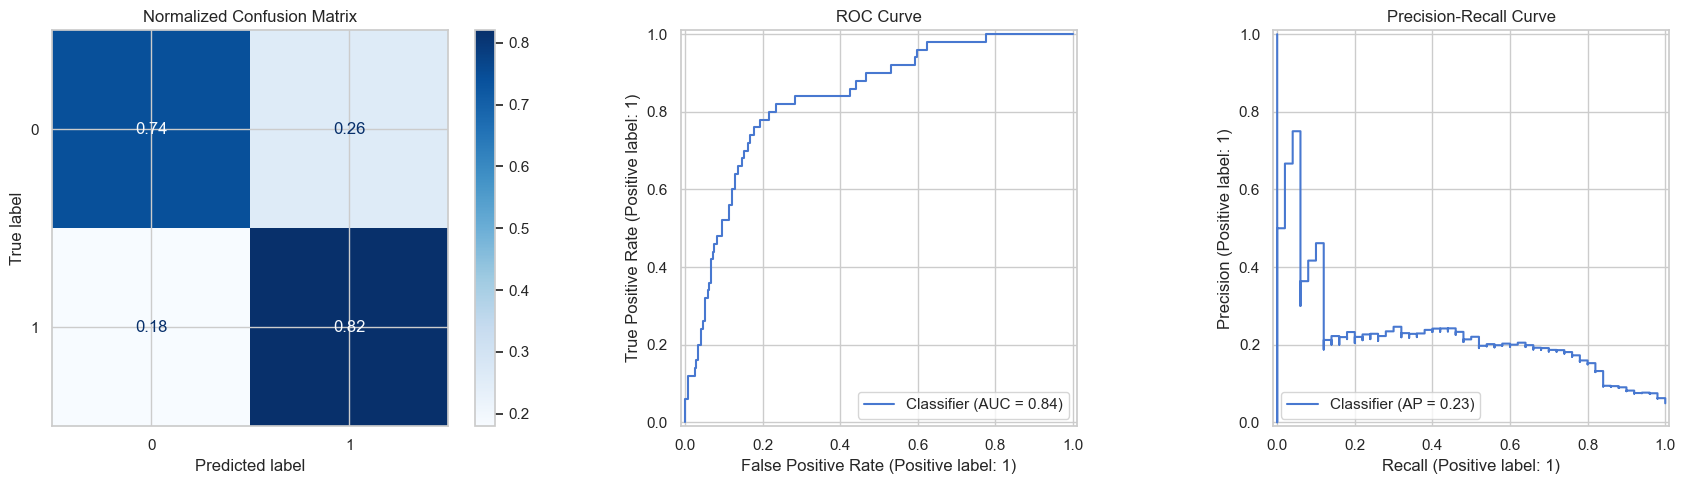

              precision    recall  f1-score   support

           0      0.988     0.741     0.847       972
           1      0.140     0.820     0.239        50

    accuracy                          0.745      1022
   macro avg      0.564     0.780     0.543      1022
weighted avg      0.946     0.745     0.817      1022



In [20]:
# Evaluation plots for the best-performing model
print(f"Diagnostics for best model ({best_model_name}) on hold-out test set")

y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, normalize='true', ax=axes[0], cmap='Blues')
axes[0].set_title('Normalized Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[1])
axes[1].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_test, digits=3))


In [21]:
def evaluate_by_group(model, X, y, group_col, min_samples=50):
    report_rows = []
    for group_value in X[group_col].dropna().unique():
        subset_mask = X[group_col] == group_value
        n_samples = subset_mask.sum()
        if n_samples < min_samples:
            continue
        metrics = performance_report(model, X[subset_mask], y[subset_mask])
        metrics.update({'group': group_value, 'n_samples': n_samples})
        report_rows.append(metrics)
    if not report_rows:
        return pd.DataFrame()
    return pd.DataFrame(report_rows).set_index('group')

for feature in ['gender', 'Residence_type', 'age_bucket']:
    print(f"\nGroup metrics for {feature} (test split):")
    display(evaluate_by_group(best_model, X_test, y_test, feature))




Group metrics for gender (test split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,,,
Male,0.828240,0.723404,0.130769,0.809524,0.225166,0.764215,423
Female,0.839322,0.759599,0.147239,0.827586,0.250000,0.791863,599



Group metrics for Residence_type (test split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,,,
Rural,0.798360,0.735354,0.119718,0.739130,0.206061,0.737150,495
Urban,0.863926,0.753321,0.158940,0.888889,0.269663,0.817444,527



Group metrics for age_bucket (test split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,,,
60-79,0.749467,0.314410,0.151351,1.0,0.262911,0.609453,229
30-44,0.575248,0.975845,0.000000,0.0,0.000000,0.500000,207
<30,0.683386,0.996875,0.000000,0.0,0.000000,0.500000,320
45-59,0.558372,0.708520,0.046154,0.5,0.084507,0.607143,223


In [22]:
# Feature importance analysis for interpretability
log_reg_interpretable = clone(log_reg_pipeline).fit(X_train_full, y_train_full)
rf_interpretable = clone(rf_pipeline).fit(X_train_full, y_train_full)

feature_names = log_reg_interpretable.named_steps['preprocess'].get_feature_names_out()
log_coefs = log_reg_interpretable.named_steps['model'].coef_[0]
log_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_coefs
})
log_coef_df['abs_coeff'] = log_coef_df['coefficient'].abs()

rf_importances = rf_interpretable.named_steps['model'].feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print("Top logistic regression coefficients (train + validation fit):")
display(log_coef_df.sort_values('abs_coeff', ascending=False).head(15))

print("Top random forest feature importances:")
display(rf_importance_df.head(15))



Top logistic regression coefficients (train + validation fit):


,feature,coefficient,abs_coeff
17,cat__work_type_children,1.735186,1.735186
0,num__age,1.696058,1.696058
28,cat__age_bucket_<30,-1.349514,1.349514
25,cat__age_bucket_45-59,1.228852,1.228852
16,cat__work_type_Self-employed,-0.809753,0.809753
13,cat__work_type_Govt_job,-0.638423,0.638423
15,cat__work_type_Private,-0.593921,0.593921
1,num__avg_glucose_level,0.429947,0.429947
12,cat__ever_married_Yes,-0.414381,0.414381
6,num__bmi_missing_flag,0.347961,0.347961


Top random forest feature importances:


,feature,importance
0,num__age,0.229201
2,num__avg_glucose_level_log,0.109578
3,num__bmi,0.108775
1,num__avg_glucose_level,0.108515
7,num__is_senior,0.072366
28,cat__age_bucket_<30,0.041045
26,cat__age_bucket_60-79,0.034170
24,cat__age_bucket_30-44,0.028205
6,num__bmi_missing_flag,0.024292
4,num__hypertension,0.021780
